# AI Gatekeeper: ANFIS (Adaptive Neuro-Fuzzy Inference System)

Notebook ini mengimplementasikan pendekatan **Neuro-Fuzzy** menggunakan **PyTorch** untuk menggantikan Random Forest.

## 🧠 konsep ANFIS (Approximation):
- **Fuzzification**: Mengubah fitur input (Volatilitas, Momentum) menjadi nilai fuzzy (Membership Degree) menggunakan fungsi Gaussian yang dapat dilatih (Learnable `sigma` & `mu`).
- **Rule Block**: Mengkombinasikan membership function (AND logic) untuk menentukan "Firing Strength" dari setiap aturan.
- **Defuzzification/Output**: Menghasilkan prediksi probabilitas Bullish/Bearish berdasarkan kekuatan aturan.

## 🛠️ Architecture:
1. **Input Layer**: 3 Fitur (Vol_20, Mom_20, Mom_50)
2. **Fuzzy Layer**: Gaussian RBF (Radial Basis Function) units untuk menangkap pola non-linear.
3. **Inference Layer**: Aggregasi logic fuzzy.
4. **Output Layer**: Sigmoid (Binary Classification).

**Note**: Implementasi ini adalah *Neuro-Fuzzy Neural Network* yang dioptimalkan dengan Gradient Descent (Adam).

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Config
plt.style.use('seaborn-v0_8')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Running on: {device}")

🚀 Running on: cpu


## 1. Data Loading & Preprocessing

In [8]:
# Load Data
file_path = 'dataset_2023_2025.xlsx'
try:
    data = pd.read_excel(file_path, index_col=0, parse_dates=True)
    print(f"Loaded {len(data)} rows of data")
except FileNotFoundError:
    print("Dataset not found, creating dummy data for demonstration (REMOVE THIS IN PROD)")
    dates = pd.date_range(start='2023-01-01', end='2025-12-31')
    data = pd.DataFrame(index=dates)
    data['Adj Close'] = (100 + np.cumsum(np.random.normal(0, 1, size=len(dates)))).clip(min=1)
    # Note: Replace with actual load if file exists

# Calculate returns
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1) # Proxy for market if multiple assets, or just single asset

# Create features
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

# Binary labeling
features['Target'] = (market_return.shift(-1) > 0).astype(int)
features = features.dropna()

# Preprocessing for Neural Net (Standard Scaling is CRITICAL)
scaler = StandardScaler()
X_raw = features[['Vol_20', 'Mom_20', 'Mom_50']].values
X_scaled = scaler.fit_transform(X_raw)
y = features['Target'].values

# Split by year
train_mask = (features.index.year >= 2023) & (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train = torch.FloatTensor(X_scaled[train_mask]).to(device)
y_train = torch.FloatTensor(y[train_mask]).unsqueeze(1).to(device)
X_test = torch.FloatTensor(X_scaled[test_mask]).to(device)
y_test = torch.FloatTensor(y[test_mask]).unsqueeze(1).to(device)
y_test_numpy = y[test_mask]

print(f"Train Shape: {X_train.shape}, Test Shape: {X_test.shape}")

Loaded 990 rows of data
Train Shape: torch.Size([562, 3]), Test Shape: torch.Size([365, 3])


## 2. Definisi Model ANFIS (Neuro-Fuzzy)

Kita membangun custom `nn.Module` yang meniru perilaku ANFIS:
1. **GaussianMembershipLayer**: Belajar `center` (mu) dan `width` (sigma) untuk setiap fitur.
2. **RuleLayer**: Mengalikan membership values (soft-AND).
3. **LinearOutput**: Kombinasi linear dari rule strengths.

In [9]:
class GaussianMembership(nn.Module):
    """
    Layer Fuzzifikasi dengan fungsi keanggotaan Gaussian.
    Parameter (mu, sigma) dapat dilatih.
    """
    def __init__(self, n_features, n_rules):
        super(GaussianMembership, self).__init__()
        self.n_features = n_features
        self.n_rules = n_rules
        
        # Inisialisasi center (mu) dan width (sigma)
        # Setiap rule memiliki 'center' sendiri di setiap dimensi fitur
        self.mu = nn.Parameter(torch.randn(n_rules, n_features) * 0.1)
        self.sigma = nn.Parameter(torch.ones(n_rules, n_features)) # Init sigma=1

    def forward(self, x):
        # x shape: (batch_size, n_features)
        # output shape: (batch_size, n_rules, n_features)
        
        x = x.unsqueeze(1) # (batch, 1, features)
        mu = self.mu.unsqueeze(0) # (1, rules, features)
        sigma = self.sigma.unsqueeze(0) # (1, rules, features)
        
        # Gaussian function: exp( -((x-mu)^2) / (2*sigma^2) )
        # Kuadrat Sigma agar selalu positif (bisa juga pakai softplus)
        squared_diff = (x - mu) ** 2
        rbf = torch.exp(-squared_diff / (2 * (sigma**2) + 1e-5))
        
        return rbf

class TorchANFIS(nn.Module):
    def __init__(self, n_features, n_rules=8):
        super(TorchANFIS, self).__init__()
        self.fuzzification = GaussianMembership(n_features, n_rules)
        
        # Output Consequent: Takagi-Sugeno Order 0 (Constanta per rule)
        # Atau Order 1 (Linear function input)
        # Disini kita pakai simplifikasi: Weighted Sum dari Rules -> Sigmoid
        self.rule_weights = nn.Linear(n_rules, 1)
        
        # Optional: Batch Norm untuk stabilitas
        self.bn = nn.BatchNorm1d(n_rules)

    def forward(self, x):
        # 1. Fuzzification
        # (batch, rules, features)
        membership_values = self.fuzzification(x) 
        
        # 2. Rule Firing Strength (Product T-Norm)
        # Mengalikan keanggotaan di seluruh fitur untuk setiap rule
        # (batch, rules)
        w = torch.prod(membership_values, dim=2)
        
        # Normalisasi firing strength (opsional di neural net, tapi standar di ANFIS)
        w_sum = torch.sum(w, dim=1, keepdim=True) + 1e-5
        w_norm = w / w_sum
        
        # 3. Defuzzification / Output
        output = self.rule_weights(w_norm) # Linear combination of normalized weights
        
        return torch.sigmoid(output)

n_features = X_train.shape[1]
n_rules = 8 # Jumlah aturan fuzzy (bisa dituning)
model = TorchANFIS(n_features, n_rules).to(device)

print(model)

TorchANFIS(
  (fuzzification): GaussianMembership()
  (rule_weights): Linear(in_features=8, out_features=1, bias=True)
  (bn): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)


## 3. Training Loop

Training Neuro-Fuzzy Gatekeeper...
Epoch 20/200, Loss: 0.6863
Epoch 40/200, Loss: 0.6853
Epoch 60/200, Loss: 0.6838
Epoch 80/200, Loss: 0.6822
Epoch 100/200, Loss: 0.6795
Epoch 120/200, Loss: 0.6731
Epoch 140/200, Loss: 0.6658
Epoch 160/200, Loss: 0.6589
Epoch 180/200, Loss: 0.6468
Epoch 200/200, Loss: 0.6356


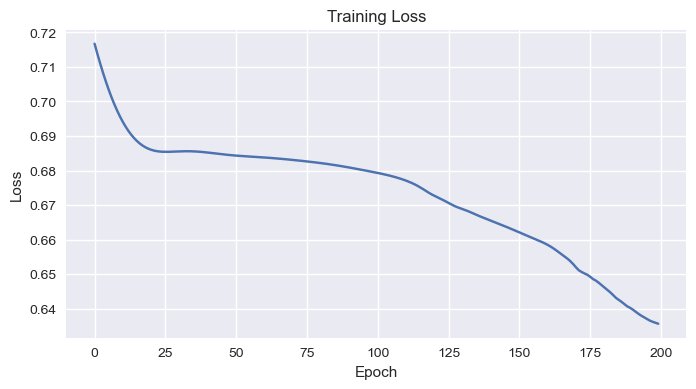

In [10]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 200
loss_history = []

print("Training Neuro-Fuzzy Gatekeeper...")
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

plt.figure(figsize=(8,4))
plt.plot(loss_history)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

## 4. Evaluation (Test Set 2025)


ANFIS (Neuro-Fuzzy) Performance - TEST 2025
Accuracy:  0.4904 (49.04%)
ROC-AUC:   0.4517

Classification Report:
              precision    recall  f1-score   support

     Bearish       0.38      0.17      0.24       167
     Bullish       0.52      0.76      0.62       198

    accuracy                           0.49       365
   macro avg       0.45      0.47      0.43       365
weighted avg       0.45      0.49      0.44       365



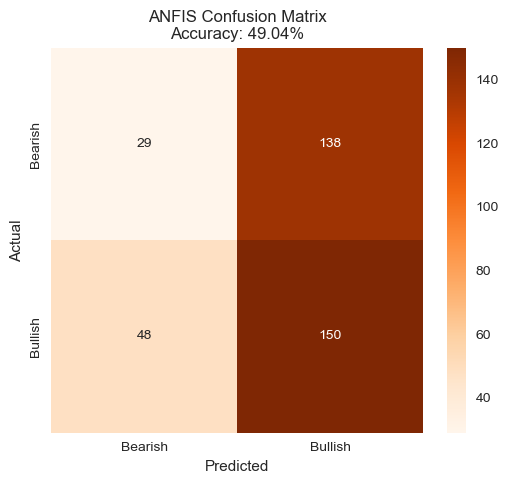

In [11]:
model.eval()
with torch.no_grad():
    y_pred_proba = model(X_test)
    y_pred = (y_pred_proba > 0.5).float()

# Convert to numpy for sklearn metrics
y_pred_np = y_pred.cpu().numpy()
y_proba_np = y_pred_proba.cpu().numpy()

accuracy = accuracy_score(y_test_numpy, y_pred_np)
roc_auc = roc_auc_score(y_test_numpy, y_proba_np)

print(f"\n{'='*50}")
print(f"ANFIS (Neuro-Fuzzy) Performance - TEST 2025")
print(f"{'='*50}")
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"ROC-AUC:   {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_numpy, y_pred_np, target_names=['Bearish', 'Bullish']))

# Confusion Matrix
cm = confusion_matrix(y_test_numpy, y_pred_np)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Bearish', 'Bullish'],
            yticklabels=['Bearish', 'Bullish'])
plt.title(f'ANFIS Confusion Matrix\nAccuracy: {accuracy:.2%}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 5. Visualizing Learned Membership Functions
Salah satu kelebihan ANFIS adalah **Interpretability**. Kita bisa melihat membership function yang dipelajari model.

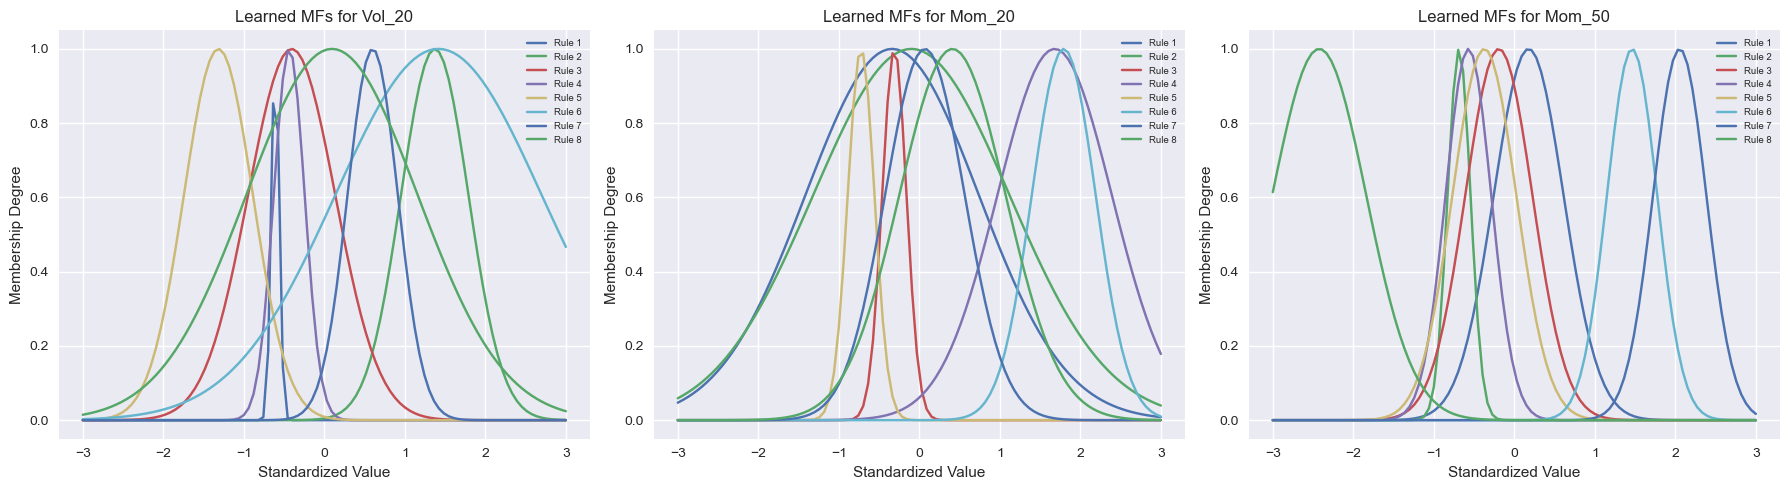

In [12]:
# Extract params
mus = model.fuzzification.mu.detach().cpu().numpy()
sigmas = model.fuzzification.sigma.detach().cpu().numpy()
feature_names = ['Vol_20', 'Mom_20', 'Mom_50']

x_range = np.linspace(-3, 3, 100) # Range dalam Standard Scaler domain

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, ax in enumerate(axes):
    ax.set_title(f"Learned MFs for {feature_names[i]}")
    for rule_idx in range(n_rules):
        mu = mus[rule_idx, i]
        sigma = sigmas[rule_idx, i]
        # Gaussian PDF formula (unnormalized for visualization)
        y_gauss = np.exp(-((x_range - mu)**2) / (2 * sigma**2))
        ax.plot(x_range, y_gauss, label=f'Rule {rule_idx+1}')
    ax.set_xlabel('Standardized Value')
    ax.set_ylabel('Membership Degree')
    ax.legend(fontsize='x-small')

plt.tight_layout()
plt.show()